In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical

In [3]:
df_train=pd.read_csv('../datasets/MNIST/train.csv')
df_test=pd.read_csv('../datasets/MNIST/test.csv')

In [9]:
df_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
df_train.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [12]:
df_train.info

<bound method DataFrame.info of        label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0          1       0       0       0       0       0       0       0       0   
1          0       0       0       0       0       0       0       0       0   
2          1       0       0       0       0       0       0       0       0   
3          4       0       0       0       0       0       0       0       0   
4          0       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995      0       0       0       0       0       0       0       0       0   
41996      1       0       0       0       0       0       0       0       0   
41997      7       0       0       0       0       0       0       0       0   
41998      6       0       0       0       0       0       0       0       0   
41999      9       0       0       0       0       0       0       0       0   

       

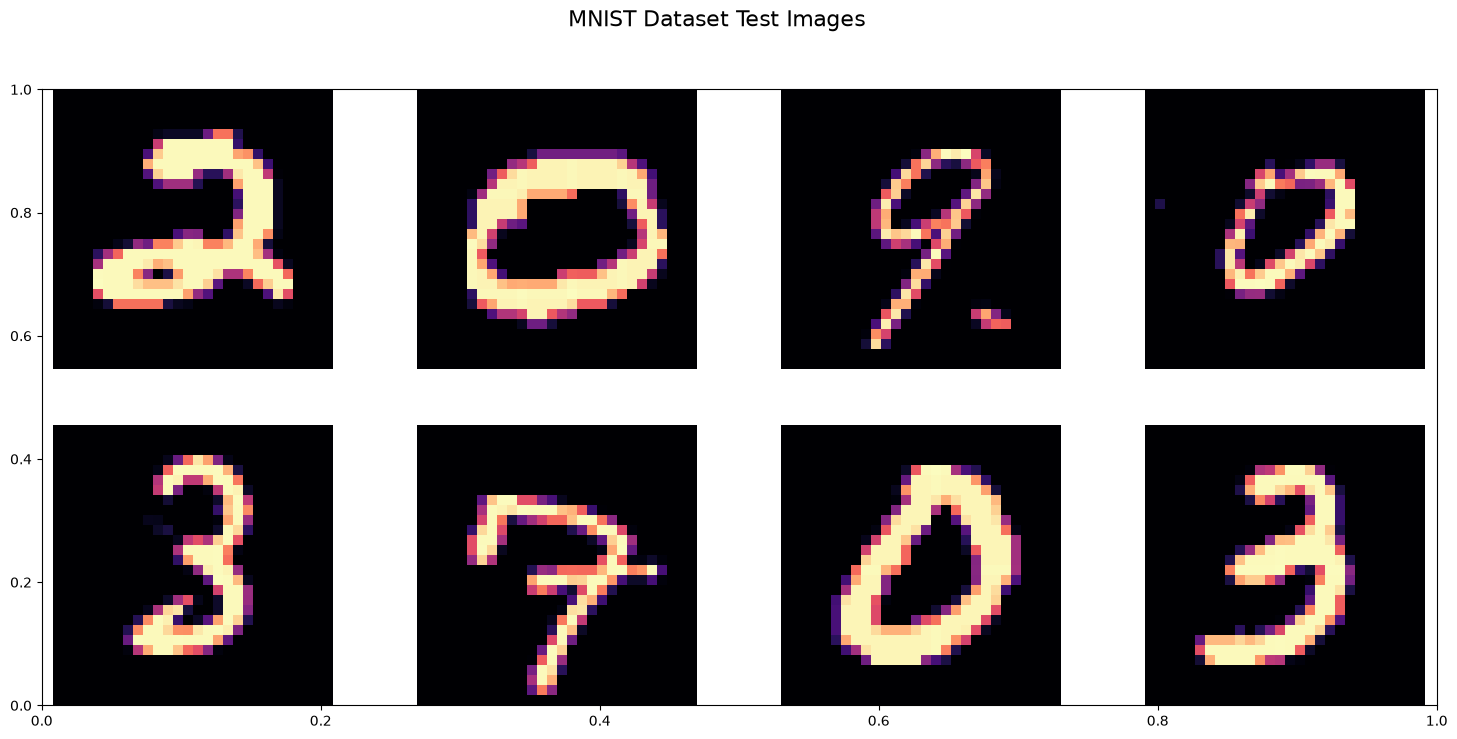

In [13]:
fig, ax = plt.subplots(figsize=(18, 8))
for ind, row in df_test.iloc[:8,:].iterrows():
    plt.subplot(2, 4, ind+1)
    img = row.to_numpy()[:].reshape(28, 28)
    fig.suptitle('MNIST Dataset Test Images', fontsize=16)
    plt.axis('off')
    plt.imshow(img, cmap='magma')

In [14]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


In [15]:
X=df_train.iloc[:,1:].to_numpy()
y=df_train['label'].to_numpy()

test=df_test.loc[:,:].to_numpy()

for i in [X,y,test]:
    print(i.shape)

(42000, 784)
(42000,)
(28000, 784)


In [16]:
X=X/255.0
test=test/255.0

In [17]:
y.shape

(42000,)

In [18]:
# Reshape

# y=y.reshape(-1,1)

print(X.shape)
print(test.shape)

X=X.reshape(-1,28,28,1)
test=test.reshape(-1,28,28,1)

print(X.shape)
print(test.shape)

(42000, 784)
(28000, 784)
(42000, 28, 28, 1)
(28000, 28, 28, 1)


In [19]:
print(y.shape)
print(y[0])
y_enc=to_categorical(y,num_classes=10)
print(y_enc.shape)
print(y_enc[0])

(42000,)
1
(42000, 10)
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [20]:
y_enc.shape

(42000, 10)

In [21]:
random_seed=2

X_train,X_val,y_train_enc,y_val_enc=train_test_split(X,y_enc,test_size=0.3)

for i in [X_train,y_train_enc,X_val,y_val_enc]:
    print(i.shape)

(29400, 28, 28, 1)
(29400, 10)
(12600, 28, 28, 1)
(12600, 10)


[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


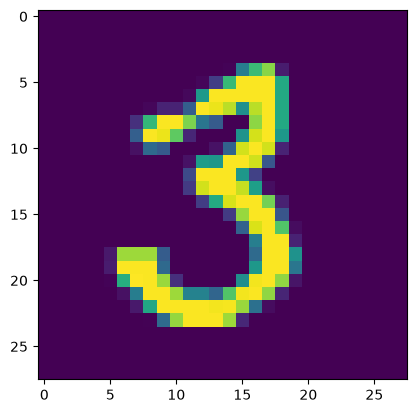

In [22]:
g=plt.imshow(X_train[0][:,:,0])

print(y_train_enc[0])

In [23]:
INPUT_SIZE=(28,28,1)
OUTPUT_SIZE=10

BATCH_SIZE=128

EPOCHS=10
VERBOSE=2

In [24]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=INPUT_SIZE))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10,activation='softmax'))

d:\Summer_PEP\PEP_LPU_GenAI\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,650 (908.79 KB)

 Trainable params: 232,650 (908.79 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history=model.fit(X_train,y_train_enc,epochs=EPOCHS,batch_size=BATCH_SIZE,verbose=VERBOSE,validation_split=0.3)

Epoch 1/10
161/161 - 7s - 44ms/step - accuracy: 0.8145 - loss: 0.5970 - val_accuracy: 0.9630 - val_loss: 0.1182
Epoch 2/10
161/161 - 4s - 24ms/step - accuracy: 0.9534 - loss: 0.1531 - val_accuracy: 0.9731 - val_loss: 0.0852
Epoch 3/10
161/161 - 4s - 25ms/step - accuracy: 0.9687 - loss: 0.1020 - val_accuracy: 0.9804 - val_loss: 0.0612
Epoch 4/10
161/161 - 4s - 25ms/step - accuracy: 0.9769 - loss: 0.0742 - val_accuracy: 0.9783 - val_loss: 0.0659
Epoch 5/10
161/161 - 4s - 26ms/step - accuracy: 0.9801 - loss: 0.0627 - val_accuracy: 0.9847 - val_loss: 0.0526
Epoch 6/10
161/161 - 4s - 24ms/step - accuracy: 0.9831 - loss: 0.0522 - val_accuracy: 0.9859 - val_loss: 0.0481
Epoch 7/10
161/161 - 4s - 24ms/step - accuracy: 0.9868 - loss: 0.0421 - val_accuracy: 0.9858 - val_loss: 0.0462
Epoch 8/10
161/161 - 4s - 27ms/step - accuracy: 0.9875 - loss: 0.0406 - val_accuracy: 0.9853 - val_loss: 0.0505
Epoch 9/10
161/161 - 4s - 23ms/step - accuracy: 0.9898 - loss: 0.0310 - val_accuracy: 0.9883 - val_loss:

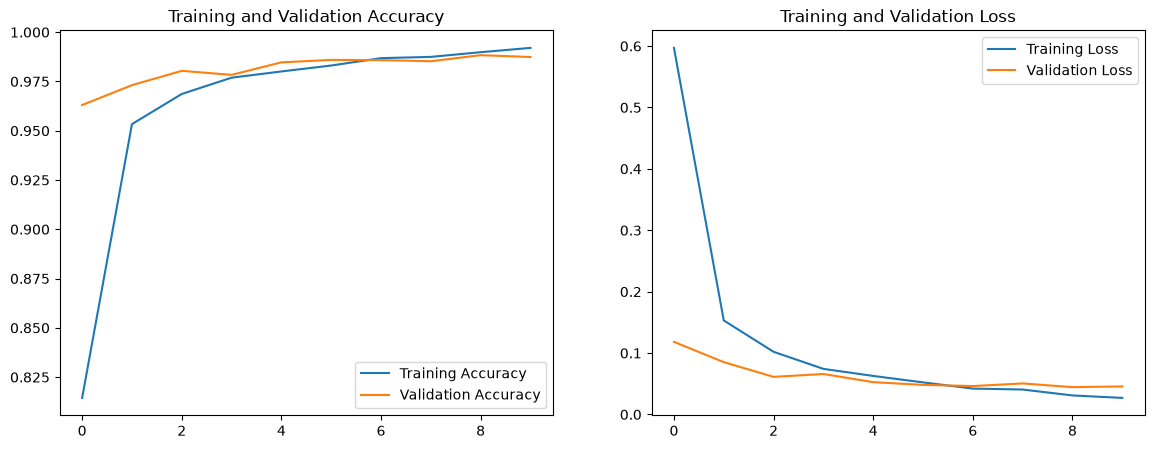

In [28]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./foo.png')
plt.show()

In [29]:
model.evaluate(X_val,y_val_enc,verbose=False)

[0.046701230108737946, 0.9876984357833862]

In [30]:
y_pred_enc=model.predict(X_val)

y_act=[np.argmax(i) for i in y_val_enc]

y_pred=[np.argmax(i) for i in y_pred_enc]

print(y_pred_enc[0])
print(y_pred[0])

394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
[2.7007039e-09 1.0781468e-10 8.6004866e-12 1.4514126e-12 7.7280777e-09
 3.7413280e-08 1.0000000e+00 8.4074566e-13 1.4136055e-08 3.2015755e-11]
6


In [31]:
print(classification_report(y_act,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1227
           1       0.99      0.99      0.99      1397
           2       0.98      0.99      0.98      1233
           3       1.00      0.98      0.99      1327
           4       0.99      0.99      0.99      1195
           5       0.99      0.98      0.99      1166
           6       0.99      0.99      0.99      1255
           7       0.98      0.99      0.99      1326
           8       0.99      0.99      0.99      1234
           9       0.99      0.98      0.98      1240

    accuracy                           0.99     12600
   macro avg       0.99      0.99      0.99     12600
weighted avg       0.99      0.99      0.99     12600



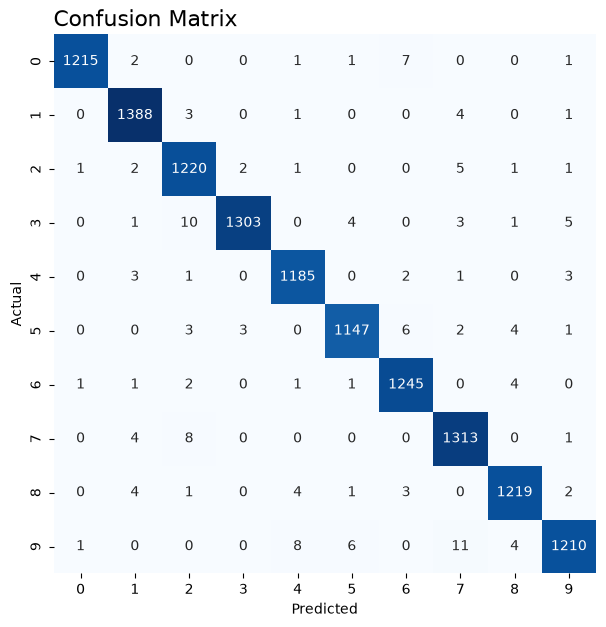

In [32]:
fig, ax=plt.subplots(figsize=(7,7))
sns.heatmap(confusion_matrix(y_act,y_pred),annot=True,cbar=False,fmt='1d',cmap='Blues',ax=ax)

ax.set_title('Confusion Matrix',loc='left',fontsize=16)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()